# IMC15 — GPU-Accelerated Fast Fourier Transform


## Environment Setup

In [1]:
import subprocess, sys
try:
    import cupy as cp
    print(f'CuPy {cp.__version__} already installed')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'cupy-cuda12x'])
    import cupy as cp

import numpy as np
import scipy, scipy.fft
from numba import cuda
import math, time, os, csv, statistics, multiprocessing, platform
import matplotlib.pyplot as plt
print('All imports OK')

CuPy 14.0.1 already installed
All imports OK


In [2]:
print('=' * 60)
print('RUNTIME INFORMATION')
print('=' * 60)
print(f'Python  : {sys.version.split()[0]}')
print(f'NumPy   : {np.__version__}')
print(f'SciPy   : {scipy.__version__}')
print(f'CuPy    : {cp.__version__}')
print(f'CPU cores: {multiprocessing.cpu_count()}')
print(f'Platform : {platform.platform()}')
n_gpus = cp.cuda.runtime.getDeviceCount()
print(f'\nGPUs detected: {n_gpus}')
for i in range(n_gpus):
    props  = cp.cuda.runtime.getDeviceProperties(i)
    name   = props['name'].decode()
    mem_gb = props['totalGlobalMem'] / 1e9
    sm_cnt = props['multiProcessorCount']
    print(f'  GPU {i}: {name}  ({mem_gb:.1f} GB, {sm_cnt} SMs)')

RUNTIME INFORMATION
Python  : 3.12.13
NumPy   : 2.0.2
SciPy   : 1.16.3
CuPy    : 14.0.1
CPU cores: 2
Platform : Linux-6.6.113+-x86_64-with-glibc2.35

GPUs detected: 1
  GPU 0: Tesla T4  (15.6 GB, 40 SMs)


---
## Problem Statement & Motivation

The **Discrete Fourier Transform (DFT)** converts N complex time-domain samples into N frequency-domain coefficients:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}, \quad k = 0, 1, \ldots, N-1$$

Direct computation is **O(N²)**. The **Fast Fourier Transform (FFT)** reduces this to **O(N log N)** via the Cooley-Tukey divide-and-conquer algorithm, making it practical for signals of millions of samples.

| Application | Why GPU matters |
|---|---|
| Audio / speech processing | Real-time spectral analysis at 48 kHz |
| Medical imaging (MRI) | Fast k-space reconstruction (512²–1024²) |
| 5G OFDM | 4096-point FFT per time slot, µs latency budget |
| Climate simulation | Spectral PDE solvers on 10⁷–10⁹ grids |
| Deep learning | Frequency-domain convolutions |

---
## Quinn Chapter 15 - Fast Fourier Transform

### Cooley-Tukey Radix-2 DIT

Split x[n] into even and odd indexed sub-sequences:

$$X[k] = X_{\text{even}}[k] + W_N^k \cdot X_{\text{odd}}[k]$$
$$X[k+N/2] = X_{\text{even}}[k] - W_N^k \cdot X_{\text{odd}}[k]$$

where $W_N^k = e^{-j2\pi k/N}$ is the **twiddle factor**, and symmetry $W_N^{k+N/2} = -W_N^k$ halves the computation — this is the **butterfly** recurrence.

### Computational Structure

| Property | Value |
|---|---|
| Stages | log₂(N) |
| Butterflies per stage | N/2 (all independent) |
| Complex multiplications | (N/2)·log₂(N) |
| Approx total FLOPs | **5·N·log₂(N)** |

For N=2²⁴: ≈200 M operations vs ≈281 T for naive DFT → **1.4 million× fewer**.

### Bit-Reversal Permutation

Before butterfly stages, input index *i* is mapped to the integer whose binary representation is the **bit-reversal** of *i* (e.g., N=8: 001₂ → 100₂, so index 1 ↔ index 4). This enables in-place computation.

### Parallel FFT

- **Within-stage:** All N/2 butterflies are **independent** → trivially parallel; each maps to one CUDA thread.
- **Across-stage:** Stage s+1 depends on stage s → **barrier synchronization** required (in CUDA: separate kernel launches).
- **Memory challenge:** Stage s has stride 2^(s-1). Late stages have stride ≈ N/2 → **non-coalesced global memory access** — primary performance bottleneck of a naive kernel.
- **Arithmetic Intensity (complex64):** OI = 5·log₂(N) / 16 FLOP/byte → **memory-bound** on all current GPUs at practical N.

## PCAM Analysis

### SciPy FFT — CPU Parallel

| PCAM | Analysis |
|------|----------|
| **Partition** | N/2 independent butterflies per stage; distribute index ranges across CPU processes |
| **Communicate** | No cross-worker communication within a stage; barrier via `multiprocessing` join between stages |
| **Agglomerate** | SciPy selects optimal chunk sizes automatically |
| **Map** | Workers → physical CPU cores; saturation at NUMA boundary or LLC pressure |

### CuPy FFT — GPU Library (cuFFT)

| PCAM | Analysis |
|------|----------|
| **Partition** | cuFFT partitions N/2 butterflies into CUDA thread blocks |
| **Communicate** | Shared memory within blocks for small sub-problems; global memory for inter-block data |
| **Agglomerate** | cuFFT auto-selects mixed-radix (2/4/8) and tile sizes based on N and GPU architecture |
| **Map** | Threads → CUDA cores; blocks → SMs; occupancy tuned by cuFFT plan optimizer |

### Numba CUDA — Custom Butterfly Kernel

| PCAM | Analysis |
|------|----------|
| **Partition** | One thread per butterfly pair; all N/2 pairs in a stage launch simultaneously |
| **Communicate** | Global memory only (no shared-memory tiling); non-coalesced access at large stages |
| **Agglomerate** | Fixed 256-thread blocks; grid = ⌈N/2 / 256⌉; one kernel launch per stage |
| **Map** | log₂(N) sequential kernel launches with `cuda.synchronize()` between them; bottleneck = global memory BW at deep stages |

## Benchmark Configuration

In [3]:
# Signal lengths — powers of 2 from 2^10 to 2^24
SIZES = [
    1 << 10,   # 1,024
    1 << 14,   # 16,384
    1 << 18,   # 262,144
    1 << 20,   # 1,048,576   (1 M)
    1 << 22,   # 4,194,304   (4 M)
    1 << 24,   # 16,777,216  (16 M)
]
DTYPES   = ['complex64', 'complex128']  # FP32 and FP64
N_WARMUP = 3
N_RUNS   = 10
SEED     = 42

# Approx FLOPs: 5N log2(N)  (butterfly: ~10 real FLOPs × N/2 × log2(N) stages)
def fft_gflops(n, seconds):
    return 5.0 * n * math.log2(n) / seconds / 1e9

print(f'Signal sizes : {[f"2^{int(math.log2(s))}" for s in SIZES]}')
print(f'Dtypes       : {DTYPES}')
print(f'Warmup/runs  : {N_WARMUP} warmup, {N_RUNS} timed (median reported)')

Signal sizes : ['2^10', '2^14', '2^18', '2^20', '2^22', '2^24']
Dtypes       : ['complex64', 'complex128']
Warmup/runs  : 3 warmup, 10 timed (median reported)


## Shared Utilities

CPU/GPU timing, signal generator, correctness metric, and CSV logger used by all implementations.

In [4]:
# ── CPU timing ────────────────────────────────────────────────────────────────
def benchmark_cpu(func, n_warmup=N_WARMUP, n_runs=N_RUNS):
    for _ in range(n_warmup): func()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter(); func()
        times.append(time.perf_counter() - t0)
    return statistics.median(times)

# ── GPU timing (CUDA events — excludes Python overhead) ───────────────────────
def benchmark_gpu(func, n_warmup=N_WARMUP, n_runs=N_RUNS):
    for _ in range(n_warmup): func()
    cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(n_runs):
        s = cp.cuda.Event(); e = cp.cuda.Event()
        s.record(); func(); e.record(); e.synchronize()
        times.append(cp.cuda.get_elapsed_time(s, e) / 1000.0)
    return statistics.median(times)

# ── Signal generator ──────────────────────────────────────────────────────────
def make_signal(n, dtype='complex64', seed=SEED):
    rng = np.random.default_rng(seed)
    fp  = np.float32 if dtype == 'complex64' else np.float64
    return (rng.standard_normal(n).astype(fp) + 1j * rng.standard_normal(n).astype(fp)).astype(dtype)

# ── Correctness metric ────────────────────────────────────────────────────────
def relative_error(result, reference):
    result = np.asarray(result, dtype=np.complex128)
    ref    = np.asarray(reference, dtype=np.complex128)
    return float(np.max(np.abs(result - ref)) / (np.max(np.abs(ref)) + 1e-12))

# ── Results log ───────────────────────────────────────────────────────────────
results_log = []

def log_result(impl, dtype, n, seconds, rel_err=None):
    results_log.append({'impl': impl, 'dtype': dtype, 'N': n,
                        'ms': round(seconds * 1000, 4),
                        'gflops': round(fft_gflops(n, seconds), 4),
                        'rel_err': rel_err})

def save_csv(path='../results/benchmarks.csv'):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['impl','dtype','N','ms','gflops','rel_err'])
        w.writeheader(); w.writerows(results_log)
    print(f'Saved {len(results_log)} rows -> {path}')

print('Utilities ready.')

Utilities ready.


## Implementation 1: Reference DFT — O(N²)

Naive Vandermonde matrix multiply. Used only as **correctness oracle** — only run for N ≤ 2^14 due to O(N²) cost.

In [5]:
def reference_dft(x):
    n   = len(x)
    idx = np.arange(n)
    W   = np.exp(-2j * np.pi * np.outer(idx, idx) / n)
    return W @ x.astype(np.complex128)

# Sanity check
x_test = make_signal(1024, 'complex64')
err_dft = relative_error(reference_dft(x_test), np.fft.fft(x_test.astype(np.complex128)))
assert err_dft < 1e-8, 'Reference DFT failed!'
print(f'Reference DFT sanity check: PASS  (err={err_dft:.2e})')

DFT_MAX_N = 1 << 14
print(f'\nBenchmarking Reference DFT (N <= {DFT_MAX_N:,})...')
print(f'{"dtype":>12s}  {"N":>12s}  {"ms":>10s}  {"GFLOP/s":>10s}')
for dtype in DTYPES:
    for n in [s for s in SIZES if s <= DFT_MAX_N]:
        x = make_signal(n, dtype)
        sec = benchmark_cpu(lambda: reference_dft(x))
        log_result('Reference DFT', dtype, n, sec, rel_err=0.0)
        print(f'{dtype:>12s}  {n:>12,d}  {sec*1000:>10.2f}  {fft_gflops(n,sec):>10.4f}')

Reference DFT sanity check: PASS  (err=1.95e-13)

Benchmarking Reference DFT (N <= 16,384)...
       dtype             N          ms     GFLOP/s
   complex64         1,024      131.73      0.0004
   complex64        16,384    14413.59      0.0001
  complex128         1,024       88.50      0.0006
  complex128        16,384    14263.62      0.0001


## Implementation 2: NumPy FFT — Serial Baseline

`np.fft.fft` uses FFTPACK under the hood (single-threaded). This is the serial CPU baseline for all speedup comparisons.

In [6]:
print('Benchmarking NumPy FFT (serial)...')
print(f'{"dtype":>12s}  {"N":>12s}  {"ms":>10s}  {"GFLOP/s":>10s}  {"rel_err":>10s}')
for dtype in DTYPES:
    for n in SIZES:
        x   = make_signal(n, dtype)
        ref = np.fft.fft(x.astype(np.complex128))
        err = relative_error(np.fft.fft(x), ref)
        sec = benchmark_cpu(lambda: np.fft.fft(x))
        log_result('NumPy FFT', dtype, n, sec, rel_err=err)
        print(f'{dtype:>12s}  {n:>12,d}  {sec*1000:>10.2f}  {fft_gflops(n,sec):>10.4f}  {err:>10.2e}')

Benchmarking NumPy FFT (serial)...
       dtype             N          ms     GFLOP/s     rel_err
   complex64         1,024        0.05      1.1131    3.73e-08
   complex64        16,384        0.34      3.3967    3.43e-08
   complex64       262,144        6.38      3.6994    4.56e-08
   complex64     1,048,576       48.57      2.1589    4.53e-08
   complex64     4,194,304      262.88      1.7551    4.65e-08
   complex64    16,777,216     1110.54      1.8129    4.18e-08
  complex128         1,024        0.02      2.8178    0.00e+00
  complex128        16,384        0.32      3.5647    0.00e+00
  complex128       262,144        6.01      3.9280    0.00e+00
  complex128     1,048,576       45.45      2.3072    0.00e+00
  complex128     4,194,304      236.35      1.9521    0.00e+00
  complex128    16,777,216     1001.10      2.0111    0.00e+00


## Implementation 3: SciPy FFT — CPU Parallel

`scipy.fft.fft(x, workers=k)` distributes sub-FFTs across *k* CPU processes using `multiprocessing`. We use all available cores.

In [7]:
N_WORKERS = multiprocessing.cpu_count()
print(f'SciPy FFT: workers = {N_WORKERS}')
print(f'{"dtype":>12s}  {"N":>12s}  {"ms":>10s}  {"GFLOP/s":>10s}  {"rel_err":>10s}')
for dtype in DTYPES:
    for n in SIZES:
        x   = make_signal(n, dtype)
        ref = np.fft.fft(x.astype(np.complex128))
        err = relative_error(scipy.fft.fft(x, workers=N_WORKERS), ref)
        sec = benchmark_cpu(lambda: scipy.fft.fft(x, workers=N_WORKERS))
        log_result('SciPy FFT', dtype, n, sec, rel_err=err)
        print(f'{dtype:>12s}  {n:>12,d}  {sec*1000:>10.2f}  {fft_gflops(n,sec):>10.4f}  {err:>10.2e}')

SciPy FFT: workers = 2
       dtype             N          ms     GFLOP/s     rel_err
   complex64         1,024        0.02      2.9171    1.07e-07
   complex64        16,384        0.20      5.6039    1.68e-07
   complex64       262,144        4.82      4.8954    1.77e-07
   complex64     1,048,576       19.80      5.2949    1.94e-07
   complex64     4,194,304      124.89      3.6941    2.26e-07
   complex64    16,777,216      599.91      3.3560    2.02e-07
  complex128         1,024        0.02      3.1730    0.00e+00
  complex128        16,384        0.23      4.9505    0.00e+00
  complex128       262,144        5.41      4.3592    0.00e+00
  complex128     1,048,576       38.44      2.7279    0.00e+00
  complex128     4,194,304      239.99      1.9225    0.00e+00
  complex128    16,777,216      866.01      2.3248    0.00e+00


## Implementation 4: CuPy FFT — GPU Library (cuFFT)

CuPy wraps NVIDIA's **cuFFT** library. Analogous to calling vendor BLAS for GEMM — maximum GPU performance with minimum effort. Data is pre-loaded to the device; timing covers GPU compute only (CUDA events).

In [8]:
print('Benchmarking CuPy FFT (cuFFT)...')
print(f'{"dtype":>12s}  {"N":>12s}  {"ms":>10s}  {"GFLOP/s":>10s}  {"rel_err":>10s}')
for dtype in DTYPES:
    for n in SIZES:
        x_cpu = make_signal(n, dtype)
        x_gpu = cp.asarray(x_cpu)
        ref   = np.fft.fft(x_cpu.astype(np.complex128))
        err   = relative_error(cp.asnumpy(cp.fft.fft(x_gpu)), ref)
        sec   = benchmark_gpu(lambda: cp.fft.fft(x_gpu))
        log_result('CuPy FFT', dtype, n, sec, rel_err=err)
        print(f'{dtype:>12s}  {n:>12,d}  {sec*1000:>10.3f}  {fft_gflops(n,sec):>10.4f}  {err:>10.2e}')

Benchmarking CuPy FFT (cuFFT)...
       dtype             N          ms     GFLOP/s     rel_err
   complex64         1,024       0.034      1.4905    2.11e-07
   complex64        16,384       0.081     14.1941    2.74e-07
   complex64       262,144       0.111    213.3951    3.22e-07
   complex64     1,048,576       0.360    291.0383    3.81e-07
   complex64     4,194,304       1.190    387.8391    3.87e-07
   complex64    16,777,216       4.297    468.5449    4.16e-07
  complex128         1,024       0.067      0.7590    3.95e-16
  complex128        16,384       0.175      6.5533    4.95e-16
  complex128       262,144       0.781     30.2226    5.34e-16
  complex128     1,048,576       3.369     31.1274    6.27e-16
  complex128     4,194,304      11.180     41.2679    6.44e-16
  complex128    16,777,216      22.025     91.4073    7.05e-16


## Implementation 5: Numba CUDA Butterfly Kernel

Hand-written iterative Cooley-Tukey FFT following Quinn exactly:

1. **Bit-reversal permutation** (CPU, O(N))
2. **log₂(N) butterfly stages** — each a separate CUDA kernel; all N/2 butterflies in a stage launch in parallel

This exposes the full GPU execution model and quantifies the gap to cuFFT.

In [9]:
# ── Bit-reversal permutation (CPU) ────────────────────────────────────────────
def bit_reverse_copy(x):
    n, bits, out = len(x), int(math.log2(len(x))), x.copy()
    for i in range(n):
        j = int(bin(i)[2:].zfill(bits)[::-1], 2)
        if j > i: out[i], out[j] = out[j], out[i]
    return out

# ── CUDA butterfly kernel (one thread per butterfly pair) ──────────────────────
@cuda.jit
def butterfly_kernel(data, stage, n):
    """
    One butterfly stage of iterative Cooley-Tukey FFT.
    Each thread handles one (i, j) pair.
    stage : 1-based stage index; half = 2^(stage-1)
    """
    tid = cuda.grid(1)
    if tid >= n // 2:
        return
    half       = 1 << (stage - 1)
    group_size = half << 1
    group      = tid // half
    k          = tid % half
    i          = group * group_size + k
    j          = i + half
    angle      = -2.0 * math.pi * k / group_size
    twiddle    = complex(math.cos(angle), math.sin(angle))
    a = data[i]; b = data[j] * twiddle
    data[i] = a + b; data[j] = a - b

# ── Full FFT ───────────────────────────────────────────────────────────────────
THREADS = 256

def numba_fft(x_cpu):
    n    = len(x_cpu)
    bits = int(math.log2(n))
    assert 2**bits == n, 'N must be a power of 2'
    x_br  = bit_reverse_copy(x_cpu.astype(np.complex128))
    d_buf = cuda.to_device(x_br)
    blocks = (n // 2 + THREADS - 1) // THREADS
    for stage in range(1, bits + 1):
        butterfly_kernel[blocks, THREADS](d_buf, stage, n)
        cuda.synchronize()
    return d_buf.copy_to_host()

# JIT warm-up
print('Compiling Numba CUDA kernel...')
_ = numba_fft(make_signal(1024, 'complex64'))
print('Kernel compiled OK.')

Compiling Numba CUDA kernel...


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Kernel compiled OK.


In [10]:
print('Benchmarking Numba CUDA FFT...')
print(f'{"dtype":>12s}  {"N":>12s}  {"ms":>10s}  {"GFLOP/s":>10s}  {"rel_err":>10s}')
for dtype in DTYPES:
    for n in SIZES:
        x_cpu = make_signal(n, dtype)
        ref   = np.fft.fft(x_cpu.astype(np.complex128))
        err   = relative_error(numba_fft(x_cpu), ref)
        # Timing: bit-reversal + H2D + kernel + D2H
        sec   = benchmark_cpu(lambda: numba_fft(x_cpu))
        log_result('Numba CUDA FFT', dtype, n, sec, rel_err=err)
        print(f'{dtype:>12s}  {n:>12,d}  {sec*1000:>10.2f}  {fft_gflops(n,sec):>10.4f}  {err:>10.2e}')

Benchmarking Numba CUDA FFT...
       dtype             N          ms     GFLOP/s     rel_err
   complex64         1,024        2.53      0.0202    7.75e-16


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


   complex64        16,384       23.30      0.0492    7.85e-16
   complex64       262,144      175.59      0.1344    1.08e-15
   complex64     1,048,576      751.29      0.1396    1.29e-15
   complex64     4,194,304     3044.06      0.1516    1.46e-15
   complex64    16,777,216    13503.29      0.1491    1.31e-15
  complex128         1,024        1.37      0.0374    5.48e-16
  complex128        16,384       11.22      0.1022    7.60e-16
  complex128       262,144      174.91      0.1349    1.12e-15
  complex128     1,048,576      768.78      0.1364    1.25e-15
  complex128     4,194,304     3110.06      0.1483    1.28e-15
  complex128    16,777,216    13536.18      0.1487    1.29e-15


## Benchmarking Summary & Plots

In [11]:
import pandas as pd
df = pd.DataFrame(results_log)
save_csv('../results/benchmarks.csv')
pivot = (df[df['dtype']=='complex64']
           .pivot_table(index='N', columns='impl', values='gflops', aggfunc='first'))
print('\nThroughput (GFLOP/s) -- complex64:')
print(pivot.to_string(float_format='{:.4f}'.format))

Saved 52 rows -> ../results/benchmarks.csv

Throughput (GFLOP/s) -- complex64:
impl      CuPy FFT  NumPy FFT  Numba CUDA FFT  Reference DFT  SciPy FFT
N                                                                      
1024        1.4905     1.1131          0.0202         0.0004     2.9171
16384      14.1941     3.3967          0.0492         0.0001     5.6039
262144    213.3951     3.6994          0.1344            NaN     4.8954
1048576   291.0383     2.1589          0.1396            NaN     5.2949
4194304   387.8391     1.7551          0.1516            NaN     3.6941
16777216  468.5449     1.8129          0.1491            NaN     3.3560


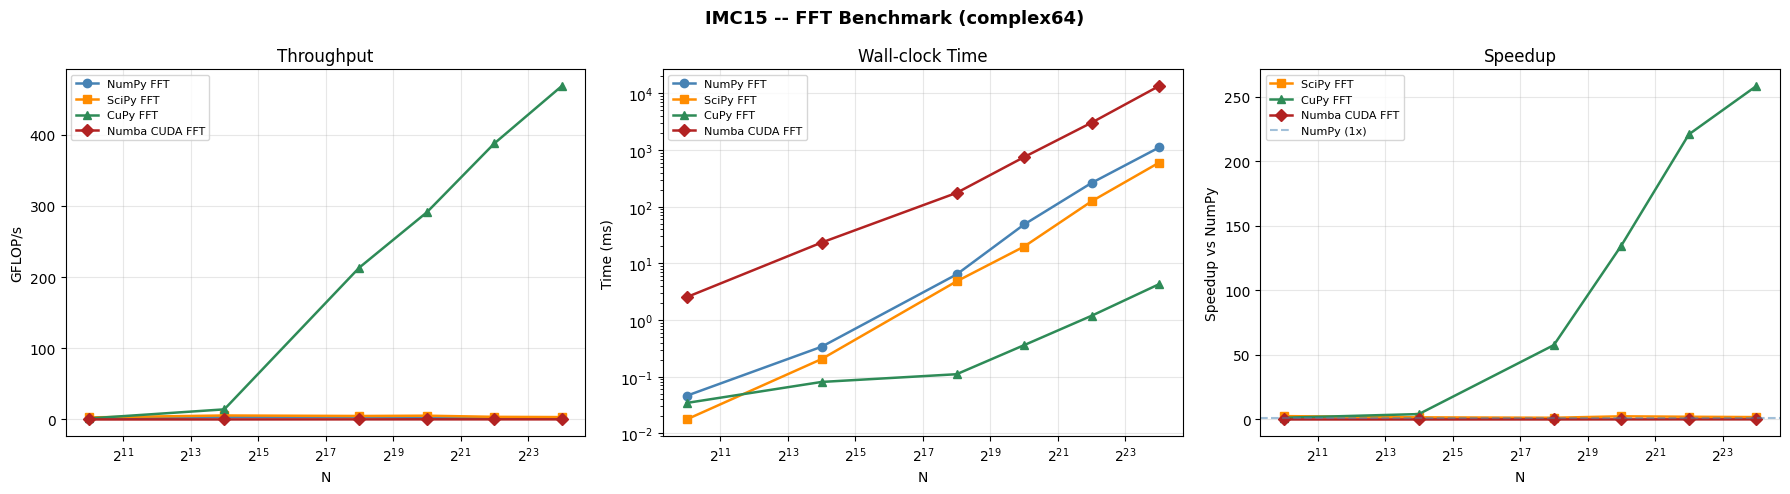

Saved -> ../results/benchmarks.png


In [12]:
IMPLS   = ['NumPy FFT', 'SciPy FFT', 'CuPy FFT', 'Numba CUDA FFT']
COLORS  = ['steelblue', 'darkorange', 'seagreen', 'firebrick']
MARKS   = ['o', 's', '^', 'D']
df64    = df[df['dtype'] == 'complex64']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IMC15 -- FFT Benchmark (complex64)', fontsize=13, fontweight='bold')

# Throughput
ax = axes[0]
for impl,c,m in zip(IMPLS, COLORS, MARKS):
    sub = df64[df64['impl']==impl].sort_values('N')
    if len(sub): ax.plot(sub['N'], sub['gflops'], marker=m, color=c, label=impl, lw=1.8)
ax.set_xscale('log', base=2); ax.set_xlabel('N'); ax.set_ylabel('GFLOP/s')
ax.set_title('Throughput'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Wall-clock
ax = axes[1]
for impl,c,m in zip(IMPLS, COLORS, MARKS):
    sub = df64[df64['impl']==impl].sort_values('N')
    if len(sub): ax.plot(sub['N'], sub['ms'], marker=m, color=c, label=impl, lw=1.8)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('N'); ax.set_ylabel('Time (ms)')
ax.set_title('Wall-clock Time'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Speedup vs NumPy
ax = axes[2]
baseline = df64[df64['impl']=='NumPy FFT'].set_index('N')['ms']
for impl,c,m in zip(IMPLS, COLORS, MARKS):
    if impl == 'NumPy FFT': continue
    sub = df64[df64['impl']==impl].sort_values('N')
    if len(sub):
        su = sub.apply(lambda r: baseline.get(r['N'], float('nan')) / r['ms'], axis=1)
        ax.plot(sub['N'].values, su.values, marker=m, color=c, label=impl, lw=1.8)
ax.axhline(1.0, color='steelblue', ls='--', alpha=0.5, label='NumPy (1x)')
ax.set_xscale('log', base=2); ax.set_xlabel('N'); ax.set_ylabel('Speedup vs NumPy')
ax.set_title('Speedup'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../results/benchmarks.png')

## Correctness Validation

In [13]:
THRESHOLD = {'complex64': 1e-5, 'complex128': 1e-11}
print('Correctness -- max relative error vs FP64 reference DFT\n')
print(f'{"Implementation":>20s}  {"dtype":>12s}  {"max err":>12s}  {"Status":>8s}')
print('-' * 60)
all_pass = True
err_piv  = df.pivot_table(index=['impl','dtype'], values='rel_err', aggfunc='max')
for (impl, dtype), row in err_piv.iterrows():
    status   = 'PASS' if row['rel_err'] < THRESHOLD[dtype] else 'FAIL'
    if status == 'FAIL': all_pass = False
    print(f'{impl:>20s}  {dtype:>12s}  {row["rel_err"]:>12.2e}  {status:>8s}')
print()
print('Overall:', 'ALL PASS' if all_pass else 'SOME FAILURES -- check above')

Correctness -- max relative error vs FP64 reference DFT

      Implementation         dtype       max err    Status
------------------------------------------------------------
            CuPy FFT    complex128      7.05e-16      PASS
            CuPy FFT     complex64      4.16e-07      PASS
           NumPy FFT    complex128      0.00e+00      PASS
           NumPy FFT     complex64      4.65e-08      PASS
      Numba CUDA FFT    complex128      1.29e-15      PASS
      Numba CUDA FFT     complex64      1.46e-15      PASS
       Reference DFT    complex128      0.00e+00      PASS
       Reference DFT     complex64      0.00e+00      PASS
           SciPy FFT    complex128      0.00e+00      PASS
           SciPy FFT     complex64      2.26e-07      PASS

Overall: ALL PASS


## Roofline Analysis

The **Roofline model** predicts whether a kernel is **memory-bound** or **compute-bound**:

$$\text{Attainable GFLOP/s} = \min\left(\text{Peak FLOP/s},\; \text{Peak BW} \times \text{OI}\right)$$

where **Arithmetic Intensity (OI)** = FLOP / byte. Kernels left of the ridge point are memory-bound; right, compute-bound.

**FFT OI (complex64):** $\text{OI} = \dfrac{5 \cdot N \log_2 N}{2 \times 8N} = \dfrac{5 \log_2 N}{16}$ FLOP/byte

In [14]:
# Auto-detect GPU hardware ceiling
props    = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = props['name'].decode()

GPU_SPECS = {
    'Tesla T4'  : (8.1,   300.0),
    'Tesla V100': (14.0,  900.0),
    'A100'      : (19.5,  2000.0),
    'L4'        : (30.3,  300.0),
    'RTX 4090'  : (82.6,  1008.0),
    'RTX 3090'  : (35.6,  936.2),
}
fp32_tf, bw_gbs = next((v for k,v in GPU_SPECS.items() if k in gpu_name), (8.1, 300.0))
PEAK_FLOPS = fp32_tf * 1000   # GFLOP/s
PEAK_BW    = bw_gbs           # GB/s
RIDGE      = PEAK_FLOPS / PEAK_BW

print(f'GPU        : {gpu_name}')
print(f'Peak FP32  : {PEAK_FLOPS:.0f} GFLOP/s')
print(f'Peak BW    : {PEAK_BW:.0f} GB/s')
print(f'Ridge point: {RIDGE:.2f} FLOP/byte')

def fft_oi(n): return 5.0 * math.log2(n) / 16.0

print(f'\n{"N":>14s}  {"log2(N)":>8s}  {"OI (F/B)":>10s}  {"Bound":>14s}')
for n in SIZES:
    oi = fft_oi(n)
    print(f'{n:>14,d}  {math.log2(n):>8.0f}  {oi:>10.2f}  {"memory-bound" if oi < RIDGE else "compute-bound":>14s}')

GPU        : Tesla T4
Peak FP32  : 8100 GFLOP/s
Peak BW    : 300 GB/s
Ridge point: 27.00 FLOP/byte

             N   log2(N)    OI (F/B)           Bound
         1,024        10        3.12    memory-bound
        16,384        14        4.38    memory-bound
       262,144        18        5.62    memory-bound
     1,048,576        20        6.25    memory-bound
     4,194,304        22        6.88    memory-bound
    16,777,216        24        7.50    memory-bound


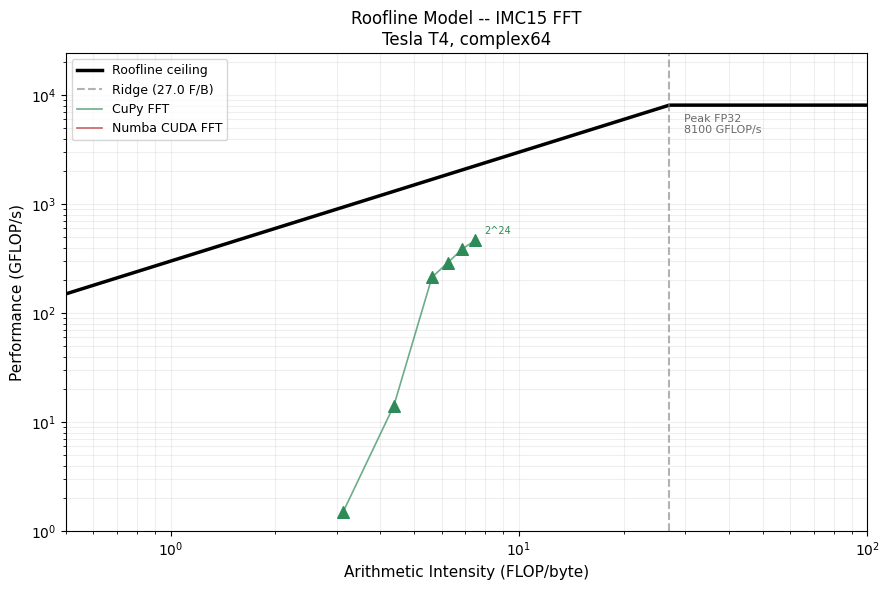

FFT OI at N=2^24: 7.50 F/B  <  ridge 27.0 F/B  -->  MEMORY-BOUND


In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

oi_r  = np.logspace(-1, 3, 1000)
roof  = np.minimum(PEAK_FLOPS, PEAK_BW * oi_r)
ax.loglog(oi_r, roof, 'k-', lw=2.5, label='Roofline ceiling')
ax.axvline(RIDGE, color='gray', ls='--', alpha=0.6, label=f'Ridge ({RIDGE:.1f} F/B)')
ax.text(RIDGE*1.1, PEAK_FLOPS*0.55, f'Peak FP32\n{PEAK_FLOPS:.0f} GFLOP/s', fontsize=8, color='dimgray')

GPU_IMPLS = ['CuPy FFT', 'Numba CUDA FFT']
GP_C = ['seagreen', 'firebrick']; GP_M = ['^', 'D']
df64 = df[df['dtype']=='complex64']
for impl, c, m in zip(GPU_IMPLS, GP_C, GP_M):
    sub = df64[df64['impl']==impl].sort_values('N')
    if not len(sub): continue
    oi_pts = sub['N'].apply(fft_oi).values
    pf_pts = sub['gflops'].values
    ax.scatter(oi_pts, pf_pts, color=c, marker=m, s=70, zorder=5)
    ax.plot(oi_pts, pf_pts, color=c, lw=1.2, alpha=0.7, label=impl)
    ax.annotate(f'2^{int(math.log2(sub["N"].iloc[-1]))}',
                (oi_pts[-1], pf_pts[-1]), xytext=(6,4),
                textcoords='offset points', fontsize=7, color=c)

ax.set_xlabel('Arithmetic Intensity (FLOP/byte)', fontsize=11)
ax.set_ylabel('Performance (GFLOP/s)', fontsize=11)
ax.set_title(f'Roofline Model -- IMC15 FFT\n{gpu_name}, complex64', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
ax.set_xlim(0.5, 100); ax.set_ylim(1, PEAK_FLOPS * 3)
plt.tight_layout()
plt.savefig('../results/roofline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'FFT OI at N=2^24: {fft_oi(SIZES[-1]):.2f} F/B  <  ridge {RIDGE:.1f} F/B  -->  MEMORY-BOUND')

## Nsight Profiling (NVTX)

NVTX annotations mark named time ranges so Nsight Systems identifies FFT kernels in the timeline.

**Colab workflow:**
1. Run this cell to execute the NVTX-annotated runs
2. In a Colab shell: `!nsys profile --trace=cuda,nvtx -o fft_profile python -c "<this_cell_code>"`
3. Download `fft_profile.nsys-rep` and open in Nsight Systems desktop app

**Nsight Compute targets** (`ncu`):
- `butterfly_kernel` — check occupancy, DRAM BW utilisation, instruction mix
- Expected: DRAM throughput near peak for cuFFT; lower for Numba kernel (strided access)

In [16]:
try:
    import nvtx
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'nvtx'])
    import nvtx

N_PROF  = 1 << 22
x_prof  = make_signal(N_PROF, 'complex64')
xg_prof = cp.asarray(x_prof)
print(f'Profiling run: N = {N_PROF:,}')

with nvtx.annotate('CuPy_FFT', color='green'):
    for _ in range(5): _ = cp.fft.fft(xg_prof)
    cp.cuda.Stream.null.synchronize()

with nvtx.annotate('Numba_CUDA_FFT', color='red'):
    for _ in range(5): _ = numba_fft(x_prof)

print('NVTX regions complete. Attach Nsight Systems to capture the timeline.')

Profiling run: N = 4,194,304
NVTX regions complete. Attach Nsight Systems to capture the timeline.
